<a href="https://colab.research.google.com/github/leandrofigueiraalmeida/LeandroFAlmeida-Challenge-Alura-Store/blob/main/Leandro_Figueira_Almeida_AluraStore_Analise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏪 Alura Store — Análise de Desempenho

**Objetivo:** Ajudar o Sr. João a decidir qual loja da rede Alura Store vender para iniciar um novo empreendimento.

Analisaremos dados de vendas, desempenho e avaliações das 4 lojas fictícias.

## 1. Carregamento dos Dados

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# URLs dos arquivos CSV

url_loja_1 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url_loja_2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url_loja_3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url_loja_4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja_1 = pd.read_csv(url_loja_1)
loja_2 = pd.read_csv(url_loja_2)
loja_3 = pd.read_csv(url_loja_3)
loja_4 = pd.read_csv(url_loja_4)

lojas = [loja_1, loja_2, loja_3, loja_4]
nomes_lojas = ['Loja 1', 'Loja 2', 'Loja 3', 'Loja 4']
cores = ['#6366F1', '#2DD4BF', '#F59E0B', '#EF4444']

print('Dados carregados com sucesso!')
for nome, loja in zip(nomes_lojas, lojas):
    print(f'{nome}: {len(loja)} registros, {loja.shape[1]} colunas')

Dados carregados com sucesso!
Loja 1: 2359 registros, 12 colunas
Loja 2: 2359 registros, 12 colunas
Loja 3: 2359 registros, 12 colunas
Loja 4: 2358 registros, 12 colunas


In [4]:
# Visualizar primeiras linhas da Loja 1
loja_1.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38


## 2. Análise do Faturamento

In [5]:
# Calcular faturamento total de cada loja
faturamentos = [loja['Preço'].sum() for loja in lojas]

for nome, fat in zip(nomes_lojas, faturamentos):
    print(f'{nome}: R$ {fat:,.2f}')

print(f'\nMaior faturamento: {nomes_lojas[np.argmax(faturamentos)]} (R$ {max(faturamentos):,.2f})')
print(f'Menor faturamento: {nomes_lojas[np.argmin(faturamentos)]} (R$ {min(faturamentos):,.2f})')

Loja 1: R$ 1,534,509.12
Loja 2: R$ 1,488,459.06
Loja 3: R$ 1,464,025.03
Loja 4: R$ 1,384,497.58

Maior faturamento: Loja 1 (R$ 1,534,509.12)
Menor faturamento: Loja 4 (R$ 1,384,497.58)


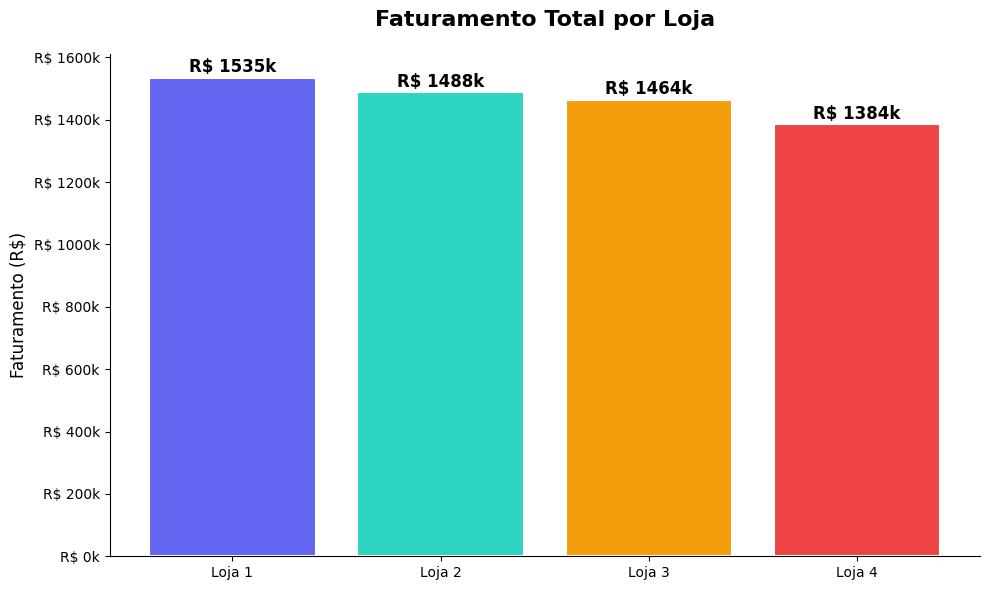

In [6]:
# Gráfico 1: Faturamento Total por Loja (Barras)
fig, ax = plt.subplots(figsize=(10, 6))
barras = ax.bar(nomes_lojas, faturamentos, color=cores, edgecolor='white', linewidth=1.5)

# Adicionar valores nas barras
for barra, fat in zip(barras, faturamentos):
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 5000,
            f'R$ {fat/1000:.0f}k', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_title('Faturamento Total por Loja', fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('Faturamento (R$)', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'R$ {x/1000:.0f}k'))
plt.tight_layout()
plt.show()

## 3. Avaliação Média dos Clientes

Loja 1: 3.98 ⭐
Loja 2: 4.04 ⭐
Loja 3: 4.05 ⭐
Loja 4: 4.00 ⭐


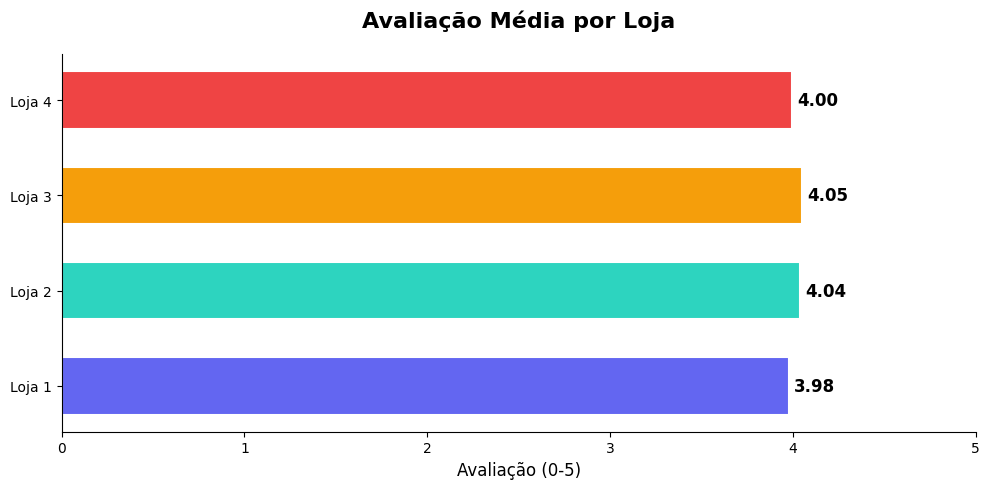

In [7]:
# Calcular avaliação média
avaliacoes = [loja['Avaliação da compra'].mean() for loja in lojas]

for nome, av in zip(nomes_lojas, avaliacoes):
    print(f'{nome}: {av:.2f} ⭐')

# Gráfico 2: Avaliação Média por Loja (Barras Horizontais)
fig, ax = plt.subplots(figsize=(10, 5))
barras = ax.barh(nomes_lojas, avaliacoes, color=cores, edgecolor='white', linewidth=1.5, height=0.6)

for barra, av in zip(barras, avaliacoes):
    ax.text(barra.get_width() + 0.03, barra.get_y() + barra.get_height()/2,
            f'{av:.2f}', ha='left', va='center', fontweight='bold', fontsize=12)

ax.set_xlim(0, 5)
ax.set_title('Avaliação Média por Loja', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Avaliação (0-5)', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 4. Frete Médio por Loja

Loja 1: R$ 34.69
Loja 2: R$ 33.62
Loja 3: R$ 33.07
Loja 4: R$ 31.28


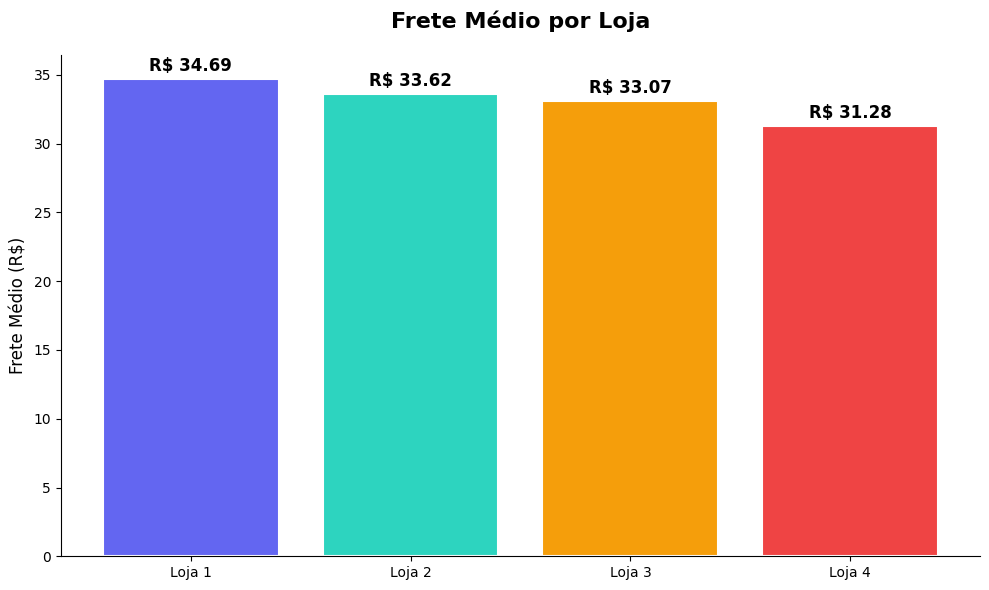

In [8]:
# Calcular frete médio
fretes = [loja['Frete'].mean() for loja in lojas]

for nome, fr in zip(nomes_lojas, fretes):
    print(f'{nome}: R$ {fr:.2f}')

# Gráfico 3: Frete Médio por Loja
fig, ax = plt.subplots(figsize=(10, 6))
barras = ax.bar(nomes_lojas, fretes, color=cores, edgecolor='white', linewidth=1.5)

for barra, fr in zip(barras, fretes):
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 0.3,
            f'R$ {fr:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_title('Frete Médio por Loja', fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('Frete Médio (R$)', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 5. Categorias Mais Vendidas

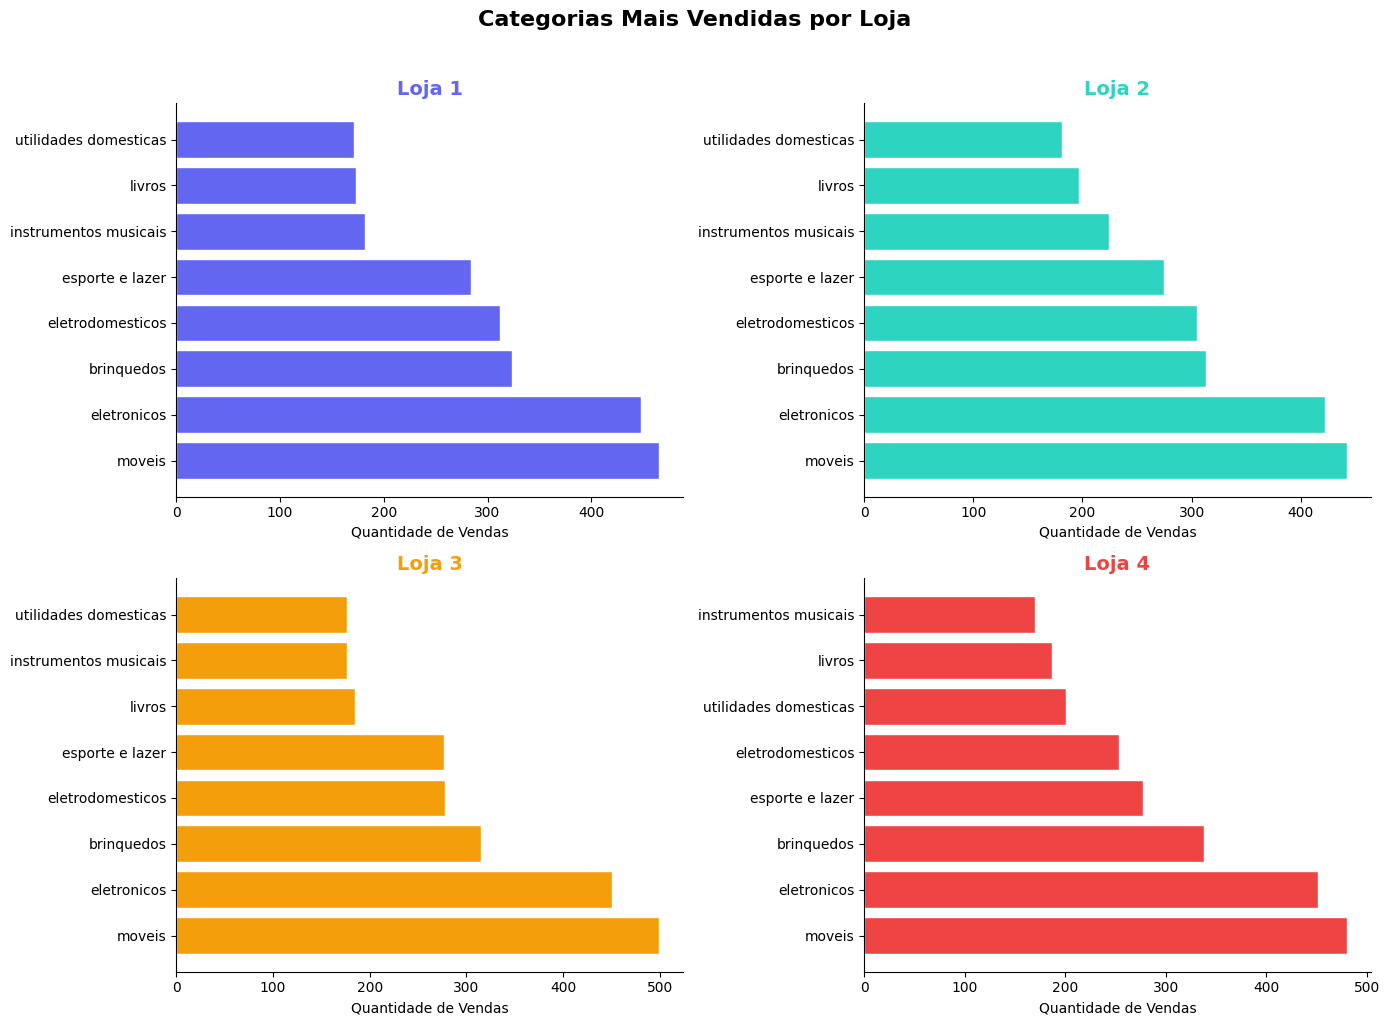

In [9]:
# Categorias mais vendidas por loja
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (loja, nome) in enumerate(zip(lojas, nomes_lojas)):
    categorias = loja['Categoria do Produto'].value_counts()
    axes[i].barh(categorias.index, categorias.values, color=cores[i], edgecolor='white')
    axes[i].set_title(f'{nome}', fontsize=14, fontweight='bold', color=cores[i])
    axes[i].spines[['top', 'right']].set_visible(False)
    axes[i].set_xlabel('Quantidade de Vendas')

plt.suptitle('Categorias Mais Vendidas por Loja', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Produtos Mais Vendidos (Top 5)

In [10]:
# Top 5 produtos mais vendidos por loja
for nome, loja, cor in zip(nomes_lojas, lojas, cores):
    top5 = loja['Produto'].value_counts().head(5)
    print(f'\n🏪 {nome}:')
    for j, (produto, qtd) in enumerate(top5.items(), 1):
        print(f'  {j}. {produto} — {qtd} vendas')


🏪 Loja 1:
  1. Micro-ondas — 60 vendas
  2. TV Led UHD 4K — 60 vendas
  3. Guarda roupas — 60 vendas
  4. Secadora de roupas — 58 vendas
  5. Cômoda — 56 vendas

🏪 Loja 2:
  1. Iniciando em programação — 65 vendas
  2. Micro-ondas — 62 vendas
  3. Bateria — 61 vendas
  4. Violão — 58 vendas
  5. Pandeiro — 58 vendas

🏪 Loja 3:
  1. Kit banquetas — 57 vendas
  2. Mesa de jantar — 56 vendas
  3. Cama king — 56 vendas
  4. Jogo de panelas — 55 vendas
  5. Cômoda — 55 vendas

🏪 Loja 4:
  1. Cama box — 62 vendas
  2. Faqueiro — 59 vendas
  3. Dashboards com Power BI — 56 vendas
  4. Cama king — 56 vendas
  5. Carrinho controle remoto — 55 vendas


## 7. Distribuição de Pagamentos (Gráfico de Pizza)

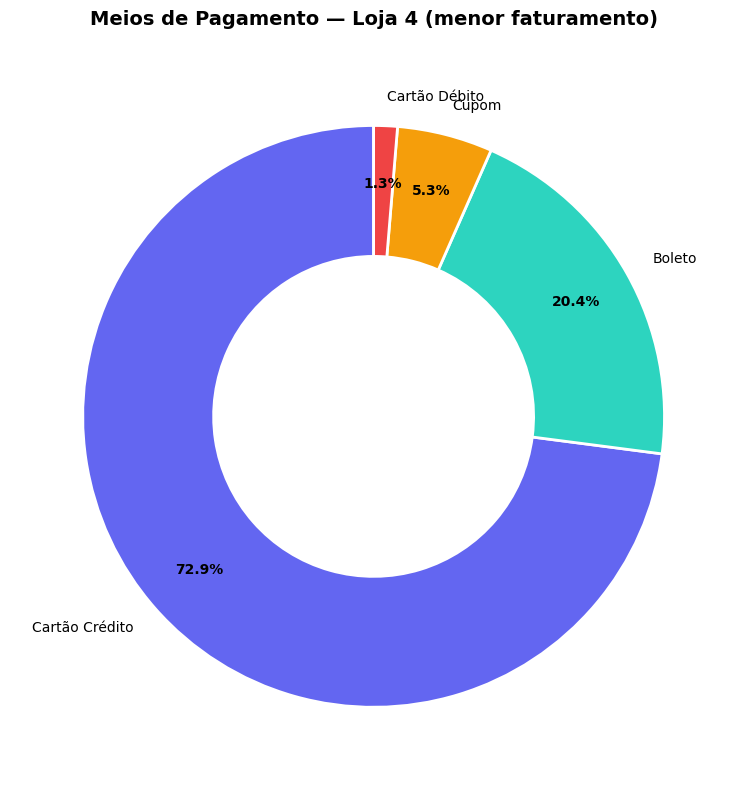

In [11]:
# Gráfico 4: Distribuição de meios de pagamento — loja com menor faturamento
idx_menor = np.argmin(faturamentos)
pagamentos = lojas[idx_menor]['Tipo de pagamento'].value_counts()

labels_map = {
    'cartao_credito': 'Cartão Crédito',
    'boleto': 'Boleto',
    'cartao_debito': 'Cartão Débito',
    'cupom': 'Cupom'
}
labels = [labels_map.get(l, l) for l in pagamentos.index]

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    pagamentos.values, labels=labels, autopct='%1.1f%%',
    colors=cores, startangle=90, pctdistance=0.8,
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2)
)
for t in autotexts:
    t.set_fontweight('bold')

ax.set_title(f'Meios de Pagamento — {nomes_lojas[idx_menor]} (menor faturamento)',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 8. Gráfico de Dispersão: Preço vs Avaliação

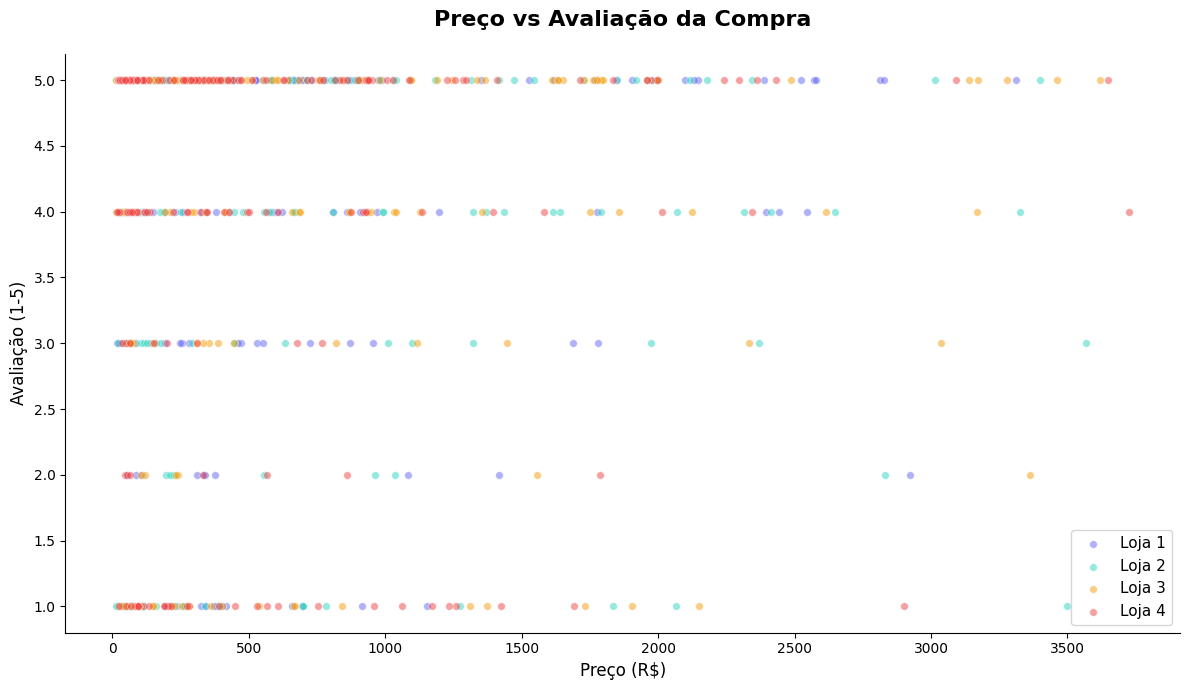

In [12]:
# Gráfico 5: Dispersão — Preço x Avaliação
fig, ax = plt.subplots(figsize=(12, 7))

for i, (loja, nome) in enumerate(zip(lojas, nomes_lojas)):
    amostra = loja.sample(min(200, len(loja)), random_state=42)
    ax.scatter(amostra['Preço'], amostra['Avaliação da compra'],
               c=cores[i], label=nome, alpha=0.5, s=30, edgecolors='white', linewidth=0.5)

ax.set_title('Preço vs Avaliação da Compra', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Preço (R$)', fontsize=12)
ax.set_ylabel('Avaliação (1-5)', fontsize=12)
ax.legend(fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 9. Pontuação Composta e Recomendação

In [13]:
# Cálculo da pontuação composta
max_fat = max(faturamentos)
max_av = 5
max_fr = max(fretes)

print('=' * 60)
print('PONTUAÇÃO COMPOSTA POR LOJA')
print('Pesos: Faturamento 40% | Avaliação 35% | Frete (inv.) 25%')
print('=' * 60)

pontuacoes = []
for i, nome in enumerate(nomes_lojas):
    p_fat = faturamentos[i] / max_fat
    p_av = avaliacoes[i] / max_av
    p_fr = 1 - fretes[i] / max_fr
    score = p_fat * 0.4 + p_av * 0.35 + p_fr * 0.25
    pontuacoes.append(score)
    print(f'{nome}: {score*100:.1f}%  (Fat: {p_fat:.2f} | Av: {p_av:.2f} | Frete inv: {p_fr:.2f})')

pior_idx = np.argmin(pontuacoes)
print(f'\n🔴 Loja com menor pontuação: {nomes_lojas[pior_idx]} ({pontuacoes[pior_idx]*100:.1f}%)')

PONTUAÇÃO COMPOSTA POR LOJA
Pesos: Faturamento 40% | Avaliação 35% | Frete (inv.) 25%
Loja 1: 67.8%  (Fat: 1.00 | Av: 0.80 | Frete inv: 0.00)
Loja 2: 67.8%  (Fat: 0.97 | Av: 0.81 | Frete inv: 0.03)
Loja 3: 67.7%  (Fat: 0.95 | Av: 0.81 | Frete inv: 0.05)
Loja 4: 66.5%  (Fat: 0.90 | Av: 0.80 | Frete inv: 0.10)

🔴 Loja com menor pontuação: Loja 4 (66.5%)


## 📊 Recomendação Final

In [14]:
pior = nomes_lojas[pior_idx]

print('=' * 60)
print(f'RECOMENDAÇÃO: O Sr. João deve vender a {pior}.')
print('=' * 60)
print(f'''
Após análise completa dos dados de vendas das 4 lojas da rede
Alura Store, a recomendação é que o Sr. João venda a {pior}.

Principais motivos:

• Faturamento: R$ {faturamentos[pior_idx]:,.2f}
  → O menor entre todas as lojas.

• Avaliação média: {avaliacoes[pior_idx]:.2f} de 5.00

• Frete médio: R$ {fretes[pior_idx]:.2f} por pedido

A análise considerou faturamento (peso 40%), avaliação dos
clientes (peso 35%) e eficiência no frete (peso 25%).

A pontuação composta da {pior} foi a mais baixa
({pontuacoes[pior_idx]*100:.1f}%), confirmando ser a loja com
menor eficiência da rede e, portanto, a melhor candidata
para venda.
''')

RECOMENDAÇÃO: O Sr. João deve vender a Loja 4.

Após análise completa dos dados de vendas das 4 lojas da rede
Alura Store, a recomendação é que o Sr. João venda a Loja 4.

Principais motivos:

• Faturamento: R$ 1,384,497.58
  → O menor entre todas as lojas.

• Avaliação média: 4.00 de 5.00

• Frete médio: R$ 31.28 por pedido

A análise considerou faturamento (peso 40%), avaliação dos
clientes (peso 35%) e eficiência no frete (peso 25%).

A pontuação composta da Loja 4 foi a mais baixa
(66.5%), confirmando ser a loja com
menor eficiência da rede e, portanto, a melhor candidata
para venda.

